# Review High-Confidence Outliers

This notebook loads the baseline high-confidence outlier CSV and prints a compact review summary for manual auditing.

In [1]:
from pathlib import Path
import pandas as pd

repo_root = Path.cwd().resolve()
if not (repo_root / 'outputs').exists():
    repo_root = repo_root.parent
csv_path = repo_root / 'grouped_audit' / 'manual_label_audit_style_genre.csv'
df = pd.read_csv(csv_path)

print(f'CSV path: {csv_path}')
print(f'Rows: {len(df)}')
print(f'Columns: {len(df.columns)}')
print('Incorrect task counts:')
print(df['incorrect_tasks'].fillna('none').value_counts().to_string())

CSV path: /Users/Lenovo/Desktop/sem 6/Gsoc_HumanAi/grouped_audit/manual_label_audit_style_genre.csv
Rows: 1
Columns: 13
Incorrect task counts:
incorrect_tasks
style,genre    1


In [2]:
review_columns= [col for col in df.columns if col.startswith('reviewer')]
print(f'Reviewer columns: {review_columns}')

Reviewer columns: []


In [3]:
review_columns = [
    'rank_in_group',
    'image_path',
    'incorrect_tasks',
    'style_true_name', 'style_pred_name',
    'genre_true_name', 'genre_pred_name',
    'artist_true_name', 'artist_pred_name',
    'mean_confidence',
    'verdict', 'suggested_label', 'notes',
]

top20 = df.loc[:19, review_columns].copy()
top20.index = top20.index + 1
top20

,rank_in_group,image_path,incorrect_tasks,style_true_name,style_pred_name,genre_true_name,genre_pred_name,artist_true_name,artist_pred_name,mean_confidence,verdict,suggested_label,notes
1,1,Analytical_Cubism/pablo-picasso_friendship-190...,"style,genre",Analytical_Cubism,Cubism,genre_painting,genre_painting,Pablo_Picasso,Pablo_Picasso,0.992998,model_error,style: Analytical_Cubism; genre: genre_painting,Manual audit: keep true labels; predicted styl...


In [4]:
multiple_error_only = df[df['incorrect_tasks'] == 'style,genre'][[
    'rank_in_group',
    'image_path',
    'style_true_name',
    'style_pred_name',
    'genre_true_name',
    'genre_pred_name',
    'mean_confidence',
    'verdict', 'suggested_label', 'notes',
]].head(20).copy()
multiple_error_only.index = multiple_error_only.index + 1
multiple_error_only

,rank_in_group,image_path,style_true_name,style_pred_name,genre_true_name,genre_pred_name,mean_confidence,verdict,suggested_label,notes
1,1,Analytical_Cubism/pablo-picasso_friendship-190...,Analytical_Cubism,Cubism,genre_painting,genre_painting,0.992998,model_error,style: Analytical_Cubism; genre: genre_painting,Manual audit: keep true labels; predicted styl...


thumbnail,rank_in_group,image_path,incorrect_tasks,style_true_name,style_pred_name,genre_true_name,genre_pred_name,mean_confidence,verdict,suggested_label,notes
,1,Analytical_Cubism/pablo-picasso_friendship-1908.jpg,"style,genre",Analytical_Cubism,Cubism,genre_painting,genre_painting,0.992998,model_error,style: Analytical_Cubism; genre: genre_painting,Manual audit: keep true labels; predicted style should be Cubism and predicted genre should be genre_painting.

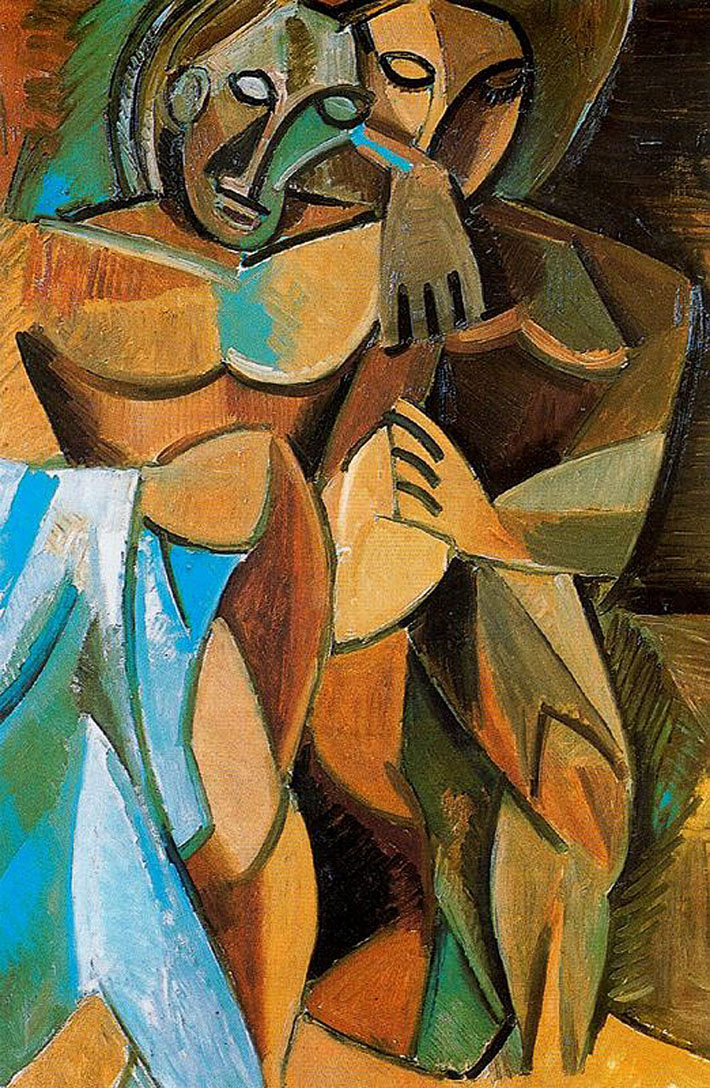

In [5]:
import base64

class HtmlDisplay(str):
    def _repr_html_(self):
        return str(self)

def image_tag(relative_path: str, width: int = 120) -> str:
    image_path = repo_root / 'data' / 'wikiart' / relative_path
    if not image_path.exists():
        return '<span style="color:#b00;">missing</span>'
    encoded = base64.b64encode(image_path.read_bytes()).decode('ascii')
    suffix = image_path.suffix.lower().lstrip('.') or 'jpeg'
    mime = 'image/jpeg' if suffix == 'jpg' else f'image/{suffix}'
    return f'<img src="data:{mime};base64,{encoded}" width="{width}" />'

review_template = df.loc[:32, [
    'rank_in_group',
    'image_path',
    'incorrect_tasks',
    'style_true_name',
    'style_pred_name',
    'genre_true_name',
    'genre_pred_name',
    'mean_confidence',
    'verdict',
    'suggested_label',
    'notes',
]].copy()
review_template.insert(0, 'thumbnail', review_template['image_path'].map(image_tag))
HtmlDisplay(review_template.to_html(escape=False, index=False))

In [6]:
repo_root = Path.cwd().resolve()
if not (repo_root / 'outputs').exists():
    repo_root = repo_root.parent
csv_path_style_genre_artist = repo_root / 'grouped_audit' / 'manual_label_audit_style_genre_artist.csv'
df_style_genre_artist = pd.read_csv(csv_path_style_genre_artist)

print(f'CSV path: {csv_path_style_genre_artist}')
print(f'Rows: {len(df_style_genre_artist)}')
print(f'Columns: {len(df_style_genre_artist.columns)}')
print('Incorrect task counts:')
print(df_style_genre_artist['incorrect_tasks'].fillna('none').value_counts().to_string())

CSV path: /Users/Lenovo/Desktop/sem 6/Gsoc_HumanAi/grouped_audit/manual_label_audit_style_genre_artist.csv
Rows: 3
Columns: 13
Incorrect task counts:
incorrect_tasks
style,genre,artist    3


In [7]:
review_columns_style_genre_artist = [col for col in df_style_genre_artist.columns if col.startswith('reviewer')]
print(f'Reviewer columns: {review_columns_style_genre_artist}')

Reviewer columns: []


In [8]:
review_columns_style_genre_artist = [
    'rank_in_group',
    'image_path',
    'incorrect_tasks',
    'style_true_name', 'style_pred_name',
    'genre_true_name', 'genre_pred_name',
    'artist_true_name', 'artist_pred_name',
    'mean_confidence',
    'verdict', 'suggested_label', 'notes',
]

top20_style_genre_artist = df_style_genre_artist.loc[:19, review_columns_style_genre_artist].copy()
top20_style_genre_artist.index = top20_style_genre_artist.index + 1
top20_style_genre_artist

,rank_in_group,image_path,incorrect_tasks,style_true_name,style_pred_name,genre_true_name,genre_pred_name,artist_true_name,artist_pred_name,mean_confidence,verdict,suggested_label,notes
1,1,Baroque/rembrandt_the-resurrection-of-lazurus-...,"style,genre,artist",Baroque,Naive_Art_Primitivism,sketch_and_study,religious_painting,Rembrandt,Marc_Chagall,0.992477,ambiguous_taxonomy,genre: religious_painting?,Religious subject and study/print taxonomy ove...
2,2,Impressionism/claude-monet_coal-dockers.jpg,"style,genre,artist",Impressionism,Art_Nouveau,genre_painting,cityscape,Claude_Monet,Nicholas_Roerich,0.990911,likely_label_issue,genre: cityscape,Genre looks more like cityscape; style and art...
3,3,Northern_Renaissance/albrecht-durer_adoration-...,"style,genre,artist",Northern_Renaissance,Baroque,sketch_and_study,religious_painting,Albrecht_Durer,Rembrandt,0.985180,likely_label_issue,genre: religious_painting,Religious subject is explicit; style and artis...


In [9]:
multiple_error_only_style_genre_artist = df_style_genre_artist[df_style_genre_artist['incorrect_tasks'] == 'style,genre,artist'][[
    'rank_in_group',
    'image_path',
    'style_true_name',
    'style_pred_name',
    'genre_true_name',
    'genre_pred_name',
    'artist_true_name',
    'artist_pred_name',
    'mean_confidence',
    'verdict', 'suggested_label', 'notes',
]].head(20).copy()
multiple_error_only_style_genre_artist.index = multiple_error_only_style_genre_artist.index + 1
multiple_error_only_style_genre_artist

,rank_in_group,image_path,style_true_name,style_pred_name,genre_true_name,genre_pred_name,artist_true_name,artist_pred_name,mean_confidence,verdict,suggested_label,notes
1,1,Baroque/rembrandt_the-resurrection-of-lazurus-...,Baroque,Naive_Art_Primitivism,sketch_and_study,religious_painting,Rembrandt,Marc_Chagall,0.992477,ambiguous_taxonomy,genre: religious_painting?,Religious subject and study/print taxonomy ove...
2,2,Impressionism/claude-monet_coal-dockers.jpg,Impressionism,Art_Nouveau,genre_painting,cityscape,Claude_Monet,Nicholas_Roerich,0.990911,likely_label_issue,genre: cityscape,Genre looks more like cityscape; style and art...
3,3,Northern_Renaissance/albrecht-durer_adoration-...,Northern_Renaissance,Baroque,sketch_and_study,religious_painting,Albrecht_Durer,Rembrandt,0.985180,likely_label_issue,genre: religious_painting,Religious subject is explicit; style and artis...


thumbnail,rank_in_group,image_path,incorrect_tasks,style_true_name,style_pred_name,genre_true_name,genre_pred_name,artist_true_name,artist_pred_name,mean_confidence,verdict,suggested_label,notes
,1,Baroque/rembrandt_the-resurrection-of-lazurus-a-small-plate-1642.jpg,"style,genre,artist",Baroque,Naive_Art_Primitivism,sketch_and_study,religious_painting,Rembrandt,Marc_Chagall,0.992477,ambiguous_taxonomy,genre: religious_painting?,Religious subject and study/print taxonomy overlap; style and artist should stay current.
,2,Impressionism/claude-monet_coal-dockers.jpg,"style,genre,artist",Impressionism,Art_Nouveau,genre_painting,cityscape,Claude_Monet,Nicholas_Roerich,0.990911,likely_label_issue,genre: cityscape,Genre looks more like cityscape; style and artist predictions are not persuasive.
,3,Northern_Renaissance/albrecht-durer_adoration-of-kings-1493.jpg,"style,genre,artist",Northern_Renaissance,Baroque,sketch_and_study,religious_painting,Albrecht_Durer,Rembrandt,0.985180,likely_label_issue,genre: religious_painting,Religious subject is explicit; style and artist should stay current.

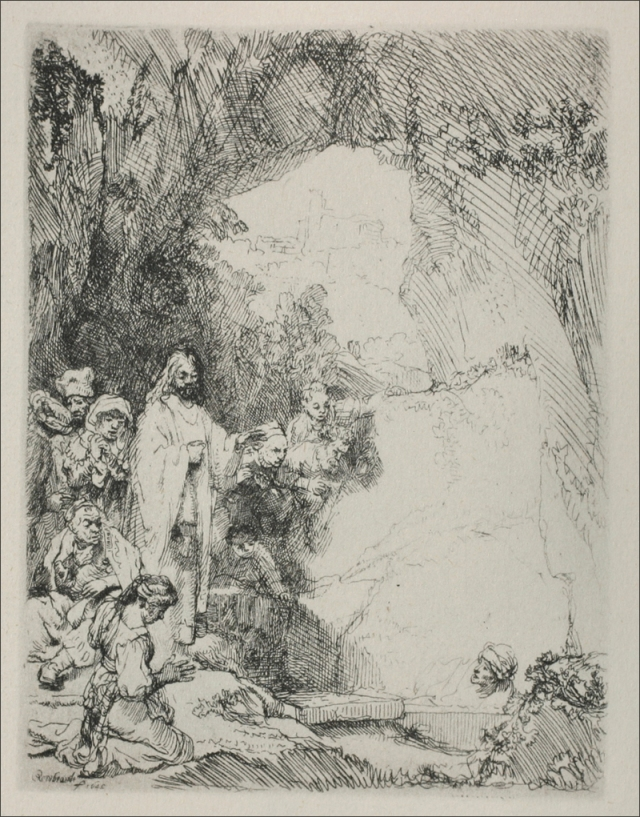
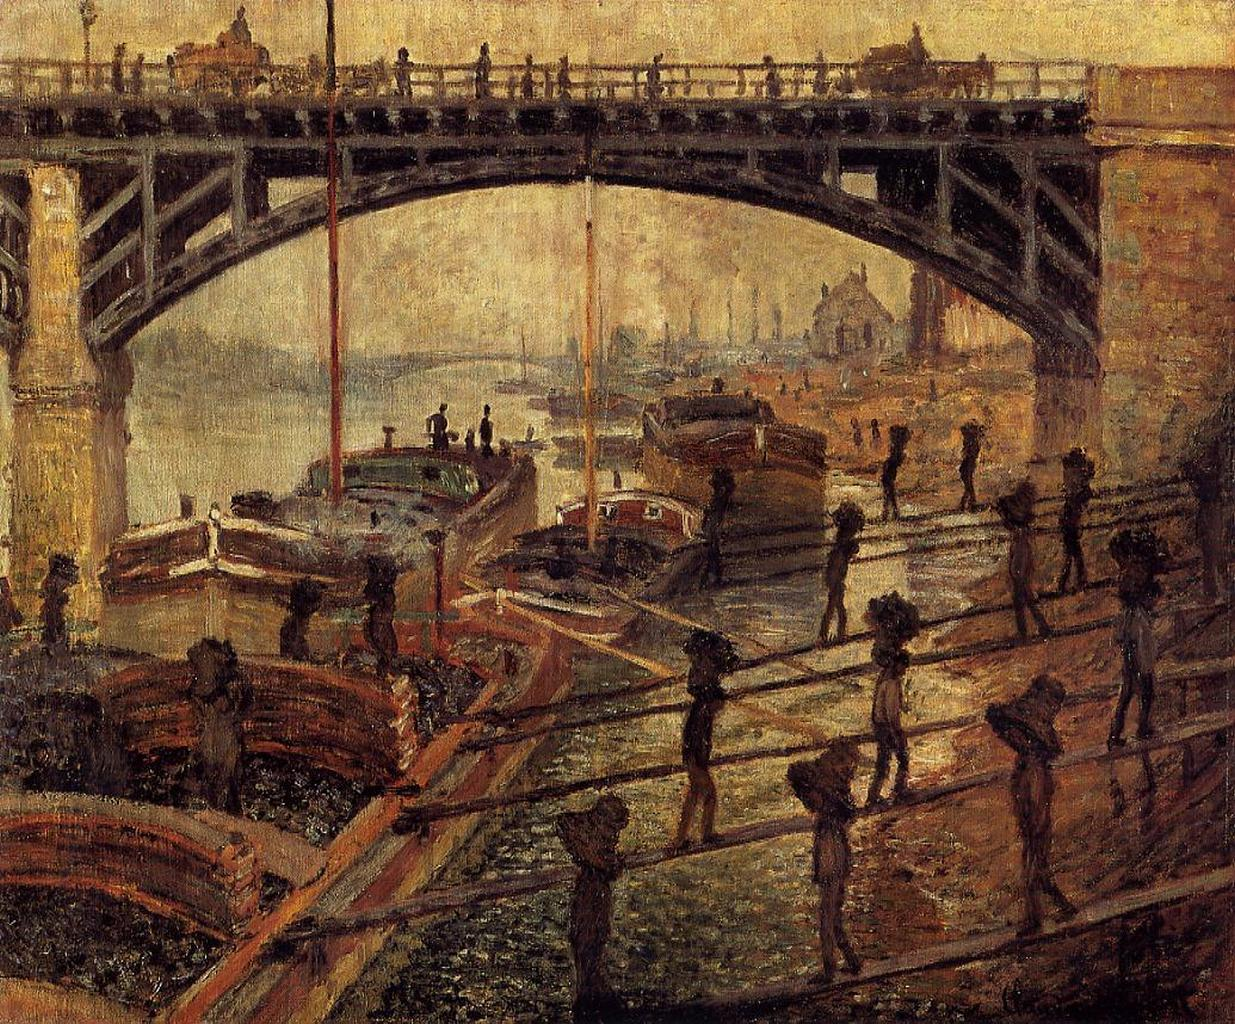
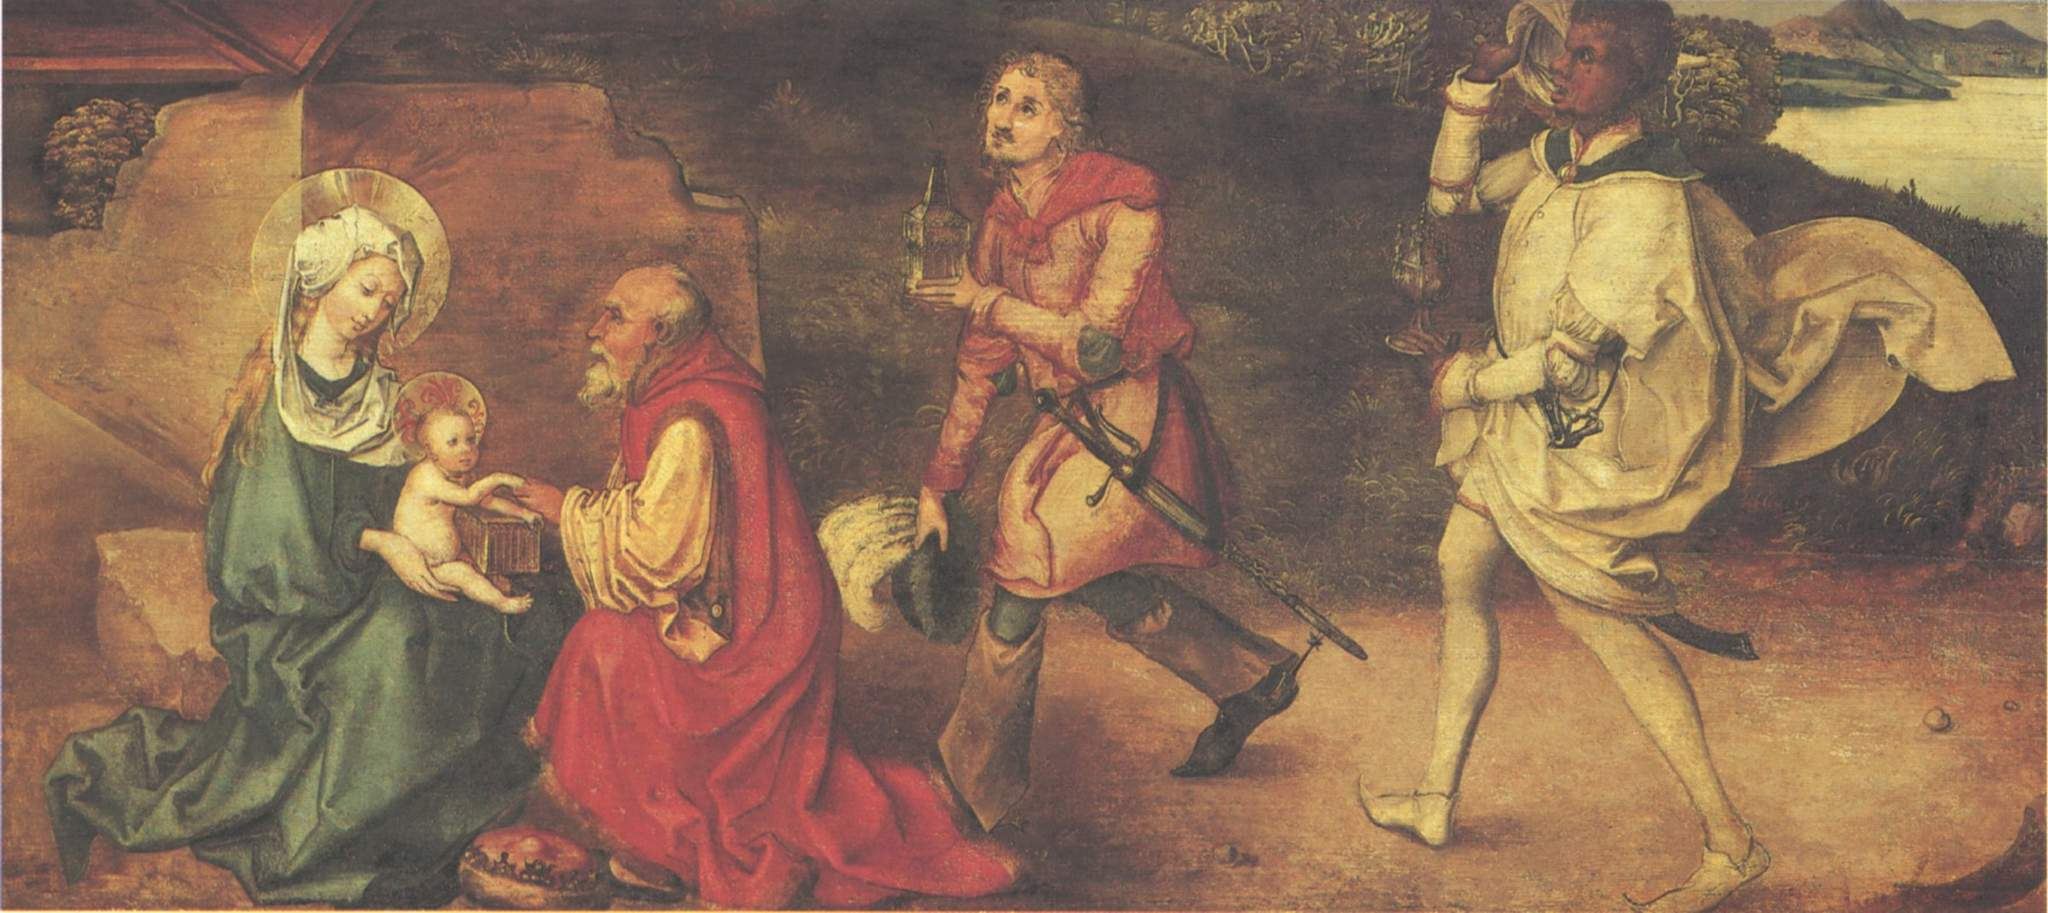

In [10]:
review_template_style_genre_artist = df_style_genre_artist.loc[:32, [
    'rank_in_group',
    'image_path',
    'incorrect_tasks',
    'style_true_name',
    'style_pred_name',
    'genre_true_name',
    'genre_pred_name',
    'artist_true_name',
    'artist_pred_name',
    'mean_confidence',
    'verdict',
    'suggested_label',
    'notes',
]].copy()
review_template_style_genre_artist.insert(0, 'thumbnail', review_template_style_genre_artist['image_path'].map(image_tag))
HtmlDisplay(review_template_style_genre_artist.to_html(escape=False, index=False))

In [11]:
repo_root = Path.cwd().resolve()
if not (repo_root / 'outputs').exists():
    repo_root = repo_root.parent
csv_path_style_artist = repo_root / 'grouped_audit' / 'manual_label_audit_style_artist.csv'
df_style_artist = pd.read_csv(csv_path_style_artist)

print(f'CSV path: {csv_path_style_artist}')
print(f'Rows: {len(df_style_artist)}')
print(f'Columns: {len(df_style_artist.columns)}')
print('Incorrect task counts:')
print(df_style_artist['incorrect_tasks'].fillna('none').value_counts().to_string())

CSV path: /Users/Lenovo/Desktop/sem 6/Gsoc_HumanAi/grouped_audit/manual_label_audit_style_artist.csv
Rows: 3
Columns: 13
Incorrect task counts:
incorrect_tasks
style,artist    3


In [12]:
review_columns_style_artist = [col for col in df_style_artist.columns if col.startswith('reviewer')]
print(f'Reviewer columns: {review_columns_style_artist}')

Reviewer columns: []


In [13]:
review_columns_style_artist = [
    'rank_in_group',
    'image_path',
    'incorrect_tasks',
    'style_true_name', 'style_pred_name',
    'genre_true_name', 'genre_pred_name',
    'artist_true_name', 'artist_pred_name',
    'mean_confidence',
    'verdict', 'suggested_label', 'notes',
]

top20_style_artist = df_style_artist.loc[:19, review_columns_style_artist].copy()
top20_style_artist.index = top20_style_artist.index + 1
top20_style_artist

,rank_in_group,image_path,incorrect_tasks,style_true_name,style_pred_name,genre_true_name,genre_pred_name,artist_true_name,artist_pred_name,mean_confidence,verdict,suggested_label,notes
1,1,Cubism/pyotr-konchalovsky_abramtsevo-the-boys-...,"style,artist",Cubism,Expressionism,sketch_and_study,sketch_and_study,Pyotr_Konchalovsky,Martiros_Saryan,0.994563,ambiguous_taxonomy,style: Expressionism?,"Sketchy handling makes the style debatable, bu..."
2,2,Cubism/pyotr-konchalovsky_abramtsevo-the-trees...,"style,artist",Cubism,Expressionism,sketch_and_study,sketch_and_study,Pyotr_Konchalovsky,Martiros_Saryan,0.994019,ambiguous_taxonomy,style: Expressionism?,"Sketchy handling makes the style debatable, bu..."
3,3,Symbolism/nicholas-roerich_himalayas-pink-peak...,"style,artist",Symbolism,Romanticism,landscape,landscape,Nicholas_Roerich,Ivan_Aivazovsky,0.974521,ambiguous_taxonomy,style: Symbolism or Romanticism,"Style boundary is debatable, but the current a..."


In [14]:
multiple_error_only_style_artist = df_style_artist[df_style_artist['incorrect_tasks'] == 'style,artist'][[
    'rank_in_group',
    'image_path',
    'style_true_name',
    'style_pred_name',
    'artist_true_name',
    'artist_pred_name',
    'mean_confidence',
    'verdict', 'suggested_label', 'notes',
]].head(20).copy()
multiple_error_only_style_artist.index = multiple_error_only_style_artist.index + 1
multiple_error_only_style_artist

,rank_in_group,image_path,style_true_name,style_pred_name,artist_true_name,artist_pred_name,mean_confidence,verdict,suggested_label,notes
1,1,Cubism/pyotr-konchalovsky_abramtsevo-the-boys-...,Cubism,Expressionism,Pyotr_Konchalovsky,Martiros_Saryan,0.994563,ambiguous_taxonomy,style: Expressionism?,"Sketchy handling makes the style debatable, bu..."
2,2,Cubism/pyotr-konchalovsky_abramtsevo-the-trees...,Cubism,Expressionism,Pyotr_Konchalovsky,Martiros_Saryan,0.994019,ambiguous_taxonomy,style: Expressionism?,"Sketchy handling makes the style debatable, bu..."
3,3,Symbolism/nicholas-roerich_himalayas-pink-peak...,Symbolism,Romanticism,Nicholas_Roerich,Ivan_Aivazovsky,0.974521,ambiguous_taxonomy,style: Symbolism or Romanticism,"Style boundary is debatable, but the current a..."


thumbnail,rank_in_group,image_path,incorrect_tasks,style_true_name,style_pred_name,genre_true_name,genre_pred_name,artist_true_name,artist_pred_name,mean_confidence,verdict,suggested_label,notes
,1,Cubism/pyotr-konchalovsky_abramtsevo-the-boys-at-the-river-drawing-for-the-painting-boys-bathing-1920.jpg,"style,artist",Cubism,Expressionism,sketch_and_study,sketch_and_study,Pyotr_Konchalovsky,Martiros_Saryan,0.994563,ambiguous_taxonomy,style: Expressionism?,"Sketchy handling makes the style debatable, but the artist label should stay current."
,2,Cubism/pyotr-konchalovsky_abramtsevo-the-trees-1920.jpg,"style,artist",Cubism,Expressionism,sketch_and_study,sketch_and_study,Pyotr_Konchalovsky,Martiros_Saryan,0.994019,ambiguous_taxonomy,style: Expressionism?,"Sketchy handling makes the style debatable, but the artist label should stay current."
,3,Symbolism/nicholas-roerich_himalayas-pink-peak.jpg,"style,artist",Symbolism,Romanticism,landscape,landscape,Nicholas_Roerich,Ivan_Aivazovsky,0.974521,ambiguous_taxonomy,style: Symbolism or Romanticism,"Style boundary is debatable, but the current artist label should stay."

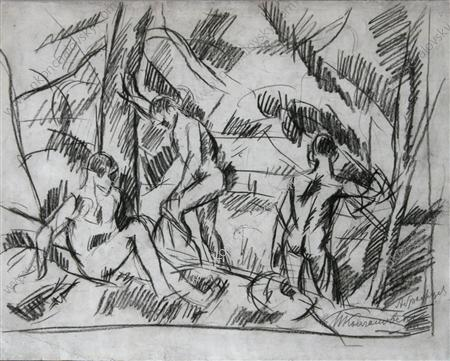
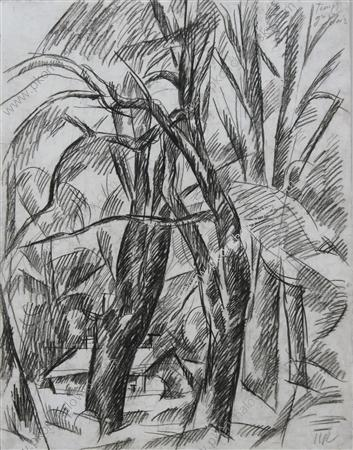
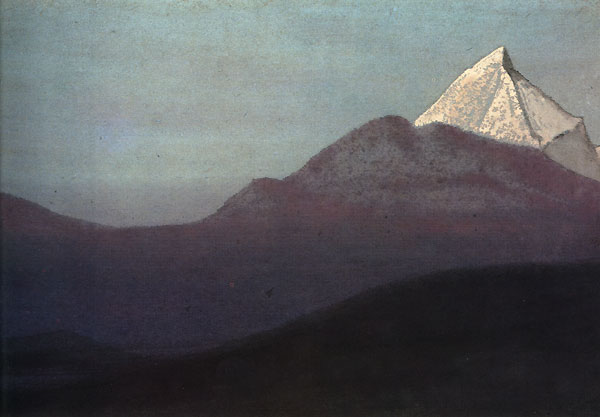

In [15]:
review_template_style_artist = df_style_artist.loc[:32, [
    'rank_in_group',
    'image_path',
    'incorrect_tasks',
    'style_true_name',
    'style_pred_name',
    'genre_true_name',
    'genre_pred_name',
    'artist_true_name',
    'artist_pred_name',
    'mean_confidence',
    'verdict',
    'suggested_label',
    'notes',
]].copy()
review_template_style_artist.insert(0, 'thumbnail', review_template_style_artist['image_path'].map(image_tag))
HtmlDisplay(review_template_style_artist.to_html(escape=False, index=False))